(1690, 2945, 3)


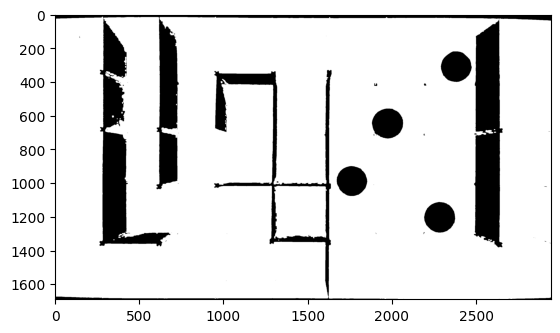

In [82]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Open an image
IMAGE_FILE = "continuous_example_2.jpeg"
thresh = 128
maxval = 255

img_maze = cv2.imread(IMAGE_FILE)
img_hsv = cv2.cvtColor(img_maze[260:1950, 480:3425], cv2.COLOR_BGR2HSV)

hsv_mask = cv2.inRange(img_hsv, (4,38,101), (27,255, 255))

_, threshed = cv2.threshold(hsv_mask, thresh, maxval, cv2.THRESH_BINARY)
threshed_3_channel = cv2.cvtColor(threshed, cv2.COLOR_GRAY2BGR)

kernel_size = 3
kernel = np.ones((kernel_size, kernel_size), np.uint8)
threshed_3_channel = cv2.dilate(threshed_3_channel, kernel, iterations = 2)

print(threshed_3_channel.shape)
pts1 = np.float32()

# plt.figure(figsize = (9,5))
plt.imshow(threshed_3_channel)
plt.show()

In [83]:


class Node:
    def __init__(self, node_id, x, y):
        self.id = node_id
        self.x = x
        self.y = y
    
    def get_point(self):
        return (self.x,self.y)
    
    def get_ID(self):
        return self.id

class Graph:
    def __init__(self):
        self.nodes = {}
        self.edges = {}

    def add_node(self, node_id, x, y):
        if node_id not in self.nodes:
            self.nodes[node_id] = Node(node_id, x, y)
            self.edges[node_id] = {}
        pass

    def add_edge(self, node_id1, node_id2, weight):
        if node_id1 in self.nodes and node_id2 in self.nodes:
            self.edges[node_id1][node_id2] = weight
            self.edges[node_id2][node_id1] = weight
        pass

    def remove_edge(self, node_id1, node_id2):
        if node_id1 in self.edges and node_id2 in self.edges[node_id1]:
            del self.edges[node_id1][node_id2]
            del self.edges[node_id2][node_id1]
        pass
    
    def get_nodes(self):
        return self.nodes
    
    def get_edge_weight(self, node_id1, node_id2):
        if node_id1 in self.edges and node_id2 in self.edges[node_id1]:
            return self.edges[node_id1][node_id2]
        return None 

In [84]:
def path_clear(image, x1, y1, x2, y2):
    height, width = image.shape[:2]
    for t in range(101):
        t /= 100.0
        x = int(x1 * (1 - t) + x2 * t)
        y = int(y1 * (1 - t) + y2 * t)
        x = max(0, min(x, width - 1))  # Clamp x
        y = max(0, min(y, height - 1))  # Clamp y
        if (image[y, x][0] == 0 and image[y, x][1] == 0 and image[y, x][2] == 0) or (image[y, x][0] == 255 and image[y, x][1] == 0 and image[y, x][2] == 0):  # Black or red
            return False
    return True


Total nodes: 91
Node ID: 0, Coordinates: (150, 150)
Node ID: 1, Coordinates: (400, 150)
Node ID: 2, Coordinates: (650, 150)
Node ID: 3, Coordinates: (900, 150)
Node ID: 4, Coordinates: (1150, 150)
Node ID: 5, Coordinates: (1400, 150)
Node ID: 6, Coordinates: (1650, 150)
Node ID: 7, Coordinates: (1900, 150)
Node ID: 8, Coordinates: (2150, 150)
Node ID: 9, Coordinates: (2400, 150)
Node ID: 10, Coordinates: (2650, 150)
Node ID: 11, Coordinates: (2900, 150)
Node ID: 12, Coordinates: (3150, 150)
Node ID: 13, Coordinates: (150, 400)
Node ID: 14, Coordinates: (400, 400)
Node ID: 15, Coordinates: (650, 400)
Node ID: 16, Coordinates: (900, 400)
Node ID: 17, Coordinates: (1150, 400)
Node ID: 18, Coordinates: (1400, 400)
Node ID: 19, Coordinates: (1650, 400)
Node ID: 20, Coordinates: (1900, 400)
Node ID: 21, Coordinates: (2150, 400)
Node ID: 22, Coordinates: (2400, 400)
Node ID: 23, Coordinates: (2650, 400)
Node ID: 24, Coordinates: (2900, 400)
Node ID: 25, Coordinates: (3150, 400)
Node ID: 26, C

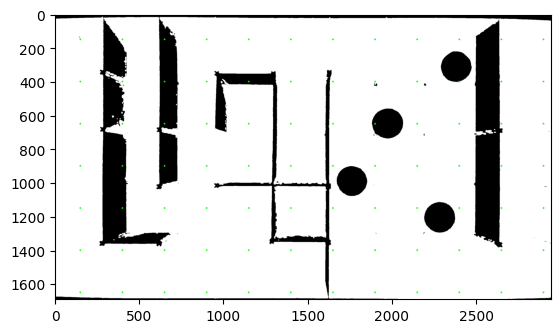

In [85]:
# Cell 4: Modified Graph Generation with Diagonal Edges and Debugging

bfs_image = threshed_3_channel.copy()
bfs_graph = Graph()

node_id = 0
size_of_node_grid = 20

# Initialize the size of the array
img_width = bfs_image.shape[1]
img_height = bfs_image.shape[0]

# Smaller grid spacing for more nodes
grid_spacing_x = 250
grid_spacing_y = 250

# Get nodes
dictionary = bfs_graph.get_nodes()
height = 7  # Adjust to fit your maze dimensions
width = 12  # Adjust to fit your maze dimensions
border = 150

# Generate nodes
for i in range(height):
    for j in range(width + 1):        
        x = border + j * grid_spacing_y
        y = border + i * grid_spacing_x
        bfs_graph.add_node(node_id, x, y)
        node_id += 1

print("Total nodes:", node_id)

# Print all nodes and their coordinates
for node_id, node in dictionary.items():
    print(f"Node ID: {node_id}, Coordinates: {node.get_point()}")

# Add horizontal and vertical edges
for i in range(0, node_id - 1, width + 1):
    for j in range(width):
        node_id1 = i + j
        node_id2 = node_id1 + 1
        if node_id2 < node_id:  # Ensure node_id2 is within bounds
            x1, y1 = dictionary[node_id1].get_point()
            x2, y2 = dictionary[node_id2].get_point()
            if path_clear(bfs_image, x1, y1, x2, y2):
                bfs_graph.add_edge(node_id1, node_id2, 1)

for i in range(width + 1):
    for j in range(0, node_id - width - 1, width + 1):
        node_id1 = i + j
        node_id2 = node_id1 + width + 1
        if node_id2 < node_id:  # Ensure node_id2 is within bounds
            x1, y1 = dictionary[node_id1].get_point()
            x2, y2 = dictionary[node_id2].get_point()
            if path_clear(bfs_image, x1, y1, x2, y2):
                bfs_graph.add_edge(node_id1, node_id2, 1)

# Add diagonal edges in the obstacle columns
obstacle_columns = [4, 5, 6]  # Example columns with round obstacles

for i in range(0, node_id - width - 1):
    for j in range(width):
        if j in obstacle_columns:
            # Add diagonal edges
            if i + width + 2 < node_id and path_clear(bfs_image, dictionary[i].get_point()[0], dictionary[i].get_point()[1], dictionary[i + width + 2].get_point()[0], dictionary[i + width + 2].get_point()[1]):
                bfs_graph.add_edge(i, i + width + 2, 1)
            if i + width < node_id and path_clear(bfs_image, dictionary[i].get_point()[0], dictionary[i].get_point()[1], dictionary[i + width].get_point()[0], dictionary[i + width].get_point()[1]):
                bfs_graph.add_edge(i, i + width, 1)

# Print all edges
for node_id, edges in bfs_graph.edges.items():
    for neighbor, weight in edges.items():
        print(f"Edge from {node_id} to {neighbor}, Weight: {weight}")

# Display nodes            
for node_id in dictionary:
    x, y = dictionary[node_id].get_point()
    cv2.circle(bfs_image, (x, y), 5, (0, 255, 0), -1)

# Display Resulting Image
plt.imshow(bfs_image)
plt.show()


Start ID: 11, Goal ID: 0
Start Coordinates: (2900, 150), Goal Coordinates: (150, 150)
Start Node Edges: {10: 1, 12: 1, 24: 1, 25: 1, 23: 1}
Goal Node Edges: {13: 1}


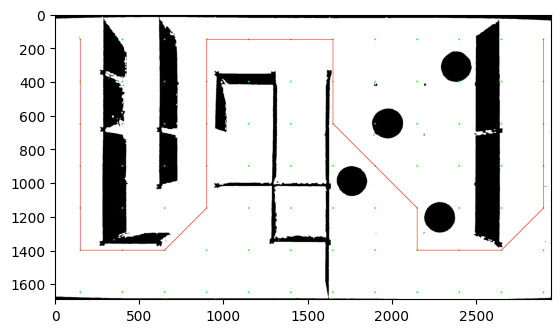

Connection: 11 -> 24
Connection: 24 -> 37
Connection: 37 -> 50
Connection: 50 -> 63
Connection: 63 -> 75
Connection: 75 -> 74
Connection: 74 -> 73
Connection: 73 -> 60
Connection: 60 -> 46
Connection: 46 -> 32
Connection: 32 -> 19
Connection: 19 -> 6
Connection: 6 -> 5
Connection: 5 -> 4
Connection: 4 -> 3
Connection: 3 -> 16
Connection: 16 -> 29
Connection: 29 -> 42
Connection: 42 -> 55
Connection: 55 -> 67
Connection: 67 -> 66
Connection: 66 -> 65
Connection: 65 -> 52
Connection: 52 -> 39
Connection: 39 -> 26
Connection: 26 -> 13
Connection: 13 -> 0


In [86]:
# Cell 5: Using Directly Specified Node IDs

# Directly specify the start and goal node IDs based on your observation
start_id = 11  # Updated based on your observation
goal_id = 0  # Updated based on your observation

# Ensure node_id is within bounds and check node coordinates
if start_id >= len(dictionary) or goal_id >= len(dictionary):
    print(f"Invalid node IDs. Start ID: {start_id}, Goal ID: {goal_id}")
else:
    print(f"Start ID: {start_id}, Goal ID: {goal_id}")
    print(f"Start Coordinates: {dictionary[start_id].get_point()}, Goal Coordinates: {dictionary[goal_id].get_point()}")

    # Check if start and goal nodes are connected to neighbors
    print(f"Start Node Edges: {bfs_graph.edges.get(start_id, 'No connections')}")
    print(f"Goal Node Edges: {bfs_graph.edges.get(goal_id, 'No connections')}")

    # BFS Pathfinding
    def bfs(graph, start, goal):
        from collections import deque
        queue = deque([start])
        visited = {start: None}
        
        while queue:
            current = queue.popleft()
            
            if current == goal:
                path = []
                while current is not None:
                    path.append(current)
                    current = visited[current]
                return path[::-1]  # Reverse the path
            
            for neighbor in graph.edges[current]:
                if neighbor not in visited:
                    visited[neighbor] = current
                    queue.append(neighbor)
        
        return None

    # Perform BFS
    path = bfs(bfs_graph, start_id, goal_id)

    if path:
        # Draw the path
        for i in range(len(path) - 1):
            node_id1 = path[i]
            node_id2 = path[i + 1]

            # Ensure node_id1 and node_id2 are connected
            if node_id2 in bfs_graph.edges[node_id1]:
                x1, y1 = dictionary[node_id1].get_point()
                x2, y2 = dictionary[node_id2].get_point()
                cv2.line(bfs_image, (x1, y1), (x2, y2), (255, 0, 0), 2)  # Draw path in blue

        plt.imshow(bfs_image)
        plt.show()
    else:
        print("No path found")

    # Check connections along the path
    if path:
        for i in range(len(path) - 1):
            print(f"Connection: {path[i]} -> {path[i+1]}")


In [ ]:
Node ID: 0, Coordinates: (150, 150)
Node 0 Connections: {13: 1}
Node ID: 1, Coordinates: (400, 150)
Node 1 Connections: {}
Node ID: 2, Coordinates: (650, 150)
Node 2 Connections: {}
Node ID: 3, Coordinates: (900, 150)
Node 3 Connections: {4: 1, 16: 1}
Node ID: 4, Coordinates: (1150, 150)
Node 4 Connections: {3: 1, 5: 1, 18: 1}
Node ID: 5, Coordinates: (1400, 150)
Node 5 Connections: {4: 1, 6: 1, 18: 1}
Node ID: 6, Coordinates: (1650, 150)
Node 6 Connections: {5: 1, 7: 1, 19: 1, 20: 1, 18: 1}
Node ID: 7, Coordinates: (1900, 150)
Node 7 Connections: {6: 1, 8: 1, 20: 1, 21: 1, 19: 1}
Node ID: 8, Coordinates: (2150, 150)
Node 8 Connections: {7: 1, 9: 1, 21: 1, 20: 1}
Node ID: 9, Coordinates: (2400, 150)
Node 9 Connections: {8: 1, 21: 1}
Node ID: 10, Coordinates: (2650, 150)
Node 10 Connections: {11: 1, 23: 1, 24: 1}
Node ID: 11, Coordinates: (2900, 150)
Node 11 Connections: {10: 1, 12: 1, 24: 1, 25: 1, 23: 1}
Node ID: 12, Coordinates: (3150, 150)
Node 12 Connections: {11: 1, 25: 1, 24: 1}
Node ID: 13, Coordinates: (150, 400)
Node 13 Connections: {0: 1, 26: 1}
Node ID: 14, Coordinates: (400, 400)
Node 14 Connections: {}
Node ID: 15, Coordinates: (650, 400)
Node 15 Connections: {}
Node ID: 16, Coordinates: (900, 400)
Node 16 Connections: {3: 1, 29: 1}
Node ID: 17, Coordinates: (1150, 400)
Node 17 Connections: {}
Node ID: 18, Coordinates: (1400, 400)
Node 18 Connections: {5: 1, 31: 1, 4: 1, 6: 1}
Node ID: 19, Coordinates: (1650, 400)
Node 19 Connections: {20: 1, 6: 1, 7: 1}
Node ID: 20, Coordinates: (1900, 400)
Node 20 Connections: {19: 1, 21: 1, 7: 1, 33: 1, 6: 1, 8: 1, 34: 1}
Node ID: 21, Coordinates: (2150, 400)
Node 21 Connections: {20: 1, 8: 1, 34: 1, 7: 1, 9: 1, 35: 1, 33: 1}
Node ID: 22, Coordinates: (2400, 400)
Node 22 Connections: {35: 1, 34: 1}
Node ID: 23, Coordinates: (2650, 400)
Node 23 Connections: {24: 1, 10: 1, 36: 1, 11: 1, 37: 1}
Node ID: 24, Coordinates: (2900, 400)
Node 24 Connections: {23: 1, 25: 1, 11: 1, 37: 1, 10: 1, 12: 1, 38: 1, 36: 1}
Node ID: 25, Coordinates: (3150, 400)
Node 25 Connections: {24: 1, 12: 1, 38: 1, 11: 1, 37: 1}
Node ID: 26, Coordinates: (150, 650)
Node 26 Connections: {13: 1, 39: 1}
Node ID: 27, Coordinates: (400, 650)
Node 27 Connections: {}
Node ID: 28, Coordinates: (650, 650)
Node 28 Connections: {}
Node ID: 29, Coordinates: (900, 650)
Node 29 Connections: {16: 1, 42: 1, 43: 1}
Node ID: 30, Coordinates: (1150, 650)
Node 30 Connections: {43: 1, 42: 1}
Node ID: 31, Coordinates: (1400, 650)
Node 31 Connections: {18: 1, 44: 1}
Node ID: 32, Coordinates: (1650, 650)
Node 32 Connections: {33: 1, 45: 1, 46: 1}
Node ID: 33, Coordinates: (1900, 650)
Node 33 Connections: {32: 1, 34: 1, 20: 1, 21: 1, 45: 1}
Node ID: 34, Coordinates: (2150, 650)
Node 34 Connections: {33: 1, 35: 1, 21: 1, 20: 1, 22: 1, 48: 1}
Node ID: 35, Coordinates: (2400, 650)
Node 35 Connections: {34: 1, 22: 1, 48: 1, 21: 1, 47: 1}
Node ID: 36, Coordinates: (2650, 650)
Node 36 Connections: {37: 1, 23: 1, 24: 1, 50: 1}
Node ID: 37, Coordinates: (2900, 650)
Node 37 Connections: {36: 1, 38: 1, 24: 1, 50: 1, 23: 1, 25: 1, 51: 1, 49: 1}
Node ID: 38, Coordinates: (3150, 650)
Node 38 Connections: {37: 1, 25: 1, 51: 1, 24: 1, 50: 1}
Node ID: 39, Coordinates: (150, 900)
Node 39 Connections: {26: 1, 52: 1}
Node ID: 40, Coordinates: (400, 900)
Node 40 Connections: {}
Node ID: 41, Coordinates: (650, 900)
Node 41 Connections: {}
Node ID: 42, Coordinates: (900, 900)
Node 42 Connections: {43: 1, 29: 1, 55: 1, 30: 1, 54: 1}
Node ID: 43, Coordinates: (1150, 900)
Node 43 Connections: {42: 1, 30: 1, 29: 1}
Node ID: 44, Coordinates: (1400, 900)
Node 44 Connections: {31: 1}
Node ID: 45, Coordinates: (1650, 900)
Node 45 Connections: {46: 1, 32: 1, 58: 1, 33: 1, 59: 1}
Node ID: 46, Coordinates: (1900, 900)
Node 46 Connections: {45: 1, 47: 1, 59: 1, 32: 1, 60: 1, 58: 1}
Node ID: 47, Coordinates: (2150, 900)
Node 47 Connections: {46: 1, 48: 1, 60: 1, 35: 1, 59: 1}
Node ID: 48, Coordinates: (2400, 900)
Node 48 Connections: {47: 1, 35: 1, 34: 1, 60: 1}
Node ID: 49, Coordinates: (2650, 900)
Node 49 Connections: {50: 1, 62: 1, 37: 1, 63: 1}
Node ID: 50, Coordinates: (2900, 900)
Node 50 Connections: {49: 1, 51: 1, 37: 1, 63: 1, 36: 1, 38: 1, 64: 1, 62: 1}
Node ID: 51, Coordinates: (3150, 900)
Node 51 Connections: {50: 1, 38: 1, 64: 1, 37: 1, 63: 1}
Node ID: 52, Coordinates: (150, 1150)
Node 52 Connections: {39: 1, 65: 1}
Node ID: 53, Coordinates: (400, 1150)
Node 53 Connections: {}
Node ID: 54, Coordinates: (650, 1150)
Node 54 Connections: {55: 1, 42: 1, 68: 1}
Node ID: 55, Coordinates: (900, 1150)
Node 55 Connections: {54: 1, 42: 1, 68: 1, 67: 1}
Node ID: 56, Coordinates: (1150, 1150)
Node 56 Connections: {57: 1, 69: 1}
Node ID: 57, Coordinates: (1400, 1150)
Node 57 Connections: {56: 1, 69: 1}
Node ID: 58, Coordinates: (1650, 1150)
Node 58 Connections: {59: 1, 45: 1, 71: 1, 46: 1}
Node ID: 59, Coordinates: (1900, 1150)
Node 59 Connections: {58: 1, 60: 1, 46: 1, 45: 1, 47: 1, 73: 1, 71: 1}
Node ID: 60, Coordinates: (2150, 1150)
Node 60 Connections: {59: 1, 47: 1, 73: 1, 46: 1, 48: 1, 74: 1}
Node ID: 61, Coordinates: (2400, 1150)
Node 61 Connections: {}
Node ID: 62, Coordinates: (2650, 1150)
Node 62 Connections: {63: 1, 49: 1, 50: 1, 76: 1}
Node ID: 63, Coordinates: (2900, 1150)
Node 63 Connections: {62: 1, 64: 1, 50: 1, 76: 1, 49: 1, 51: 1, 77: 1, 75: 1}
Node ID: 64, Coordinates: (3150, 1150)
Node 64 Connections: {63: 1, 51: 1, 77: 1, 50: 1, 76: 1}
Node ID: 65, Coordinates: (150, 1400)
Node 65 Connections: {66: 1, 52: 1, 78: 1, 79: 1}
Node ID: 66, Coordinates: (400, 1400)
Node 66 Connections: {65: 1, 67: 1, 79: 1, 80: 1, 78: 1}
Node ID: 67, Coordinates: (650, 1400)
Node 67 Connections: {66: 1, 68: 1, 80: 1, 55: 1, 81: 1, 79: 1}
Node ID: 68, Coordinates: (900, 1400)
Node 68 Connections: {67: 1, 69: 1, 55: 1, 81: 1, 54: 1, 82: 1, 80: 1}
Node ID: 69, Coordinates: (1150, 1400)
Node 69 Connections: {68: 1, 70: 1, 56: 1, 82: 1, 57: 1, 83: 1, 81: 1}
Node ID: 70, Coordinates: (1400, 1400)
Node 70 Connections: {69: 1, 83: 1, 82: 1}
Node ID: 71, Coordinates: (1650, 1400)
Node 71 Connections: {58: 1, 84: 1, 59: 1, 85: 1}
Node ID: 72, Coordinates: (1900, 1400)
Node 72 Connections: {}
Node ID: 73, Coordinates: (2150, 1400)
Node 73 Connections: {74: 1, 60: 1, 86: 1, 59: 1, 87: 1, 85: 1}
Node ID: 74, Coordinates: (2400, 1400)
Node 74 Connections: {73: 1, 75: 1, 87: 1, 60: 1, 88: 1, 86: 1}
Node ID: 75, Coordinates: (2650, 1400)
Node 75 Connections: {74: 1, 76: 1, 88: 1, 63: 1, 89: 1, 87: 1}
Node ID: 76, Coordinates: (2900, 1400)
Node 76 Connections: {75: 1, 77: 1, 63: 1, 89: 1, 62: 1, 64: 1, 88: 1}
Node ID: 77, Coordinates: (3150, 1400)
Node 77 Connections: {76: 1, 64: 1, 63: 1}
Node ID: 78, Coordinates: (150, 1650)
Node 78 Connections: {79: 1, 65: 1, 66: 1}
Node ID: 79, Coordinates: (400, 1650)
Node 79 Connections: {78: 1, 80: 1, 66: 1, 65: 1, 67: 1}
Node ID: 80, Coordinates: (650, 1650)
Node 80 Connections: {79: 1, 81: 1, 67: 1, 66: 1, 68: 1}
Node ID: 81, Coordinates: (900, 1650)
Node 81 Connections: {80: 1, 82: 1, 68: 1, 67: 1, 69: 1}
Node ID: 82, Coordinates: (1150, 1650)
Node 82 Connections: {81: 1, 83: 1, 69: 1, 68: 1, 70: 1}
Node ID: 83, Coordinates: (1400, 1650)
Node 83 Connections: {82: 1, 70: 1, 69: 1}
Node ID: 84, Coordinates: (1650, 1650)
Node 84 Connections: {85: 1, 71: 1}
Node ID: 85, Coordinates: (1900, 1650)
Node 85 Connections: {84: 1, 86: 1, 71: 1, 73: 1}
Node ID: 86, Coordinates: (2150, 1650)
Node 86 Connections: {85: 1, 87: 1, 73: 1, 74: 1}
Node ID: 87, Coordinates: (2400, 1650)
Node 87 Connections: {86: 1, 88: 1, 74: 1, 73: 1, 75: 1}
Node ID: 88, Coordinates: (2650, 1650)
Node 88 Connections: {87: 1, 89: 1, 75: 1, 74: 1, 76: 1}
Node ID: 89, Coordinates: (2900, 1650)
Node 89 Connections: {88: 1, 76: 1, 75: 1}
Node ID: 90, Coordinates: (3150, 1650)
Node 90 Connections: {}